<a href="https://colab.research.google.com/github/alexis-chaesong/Vision-AI-Notebooks/blob/main/01_CIFAR10_Image_Classification/CIFAR10_Classification_Evolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

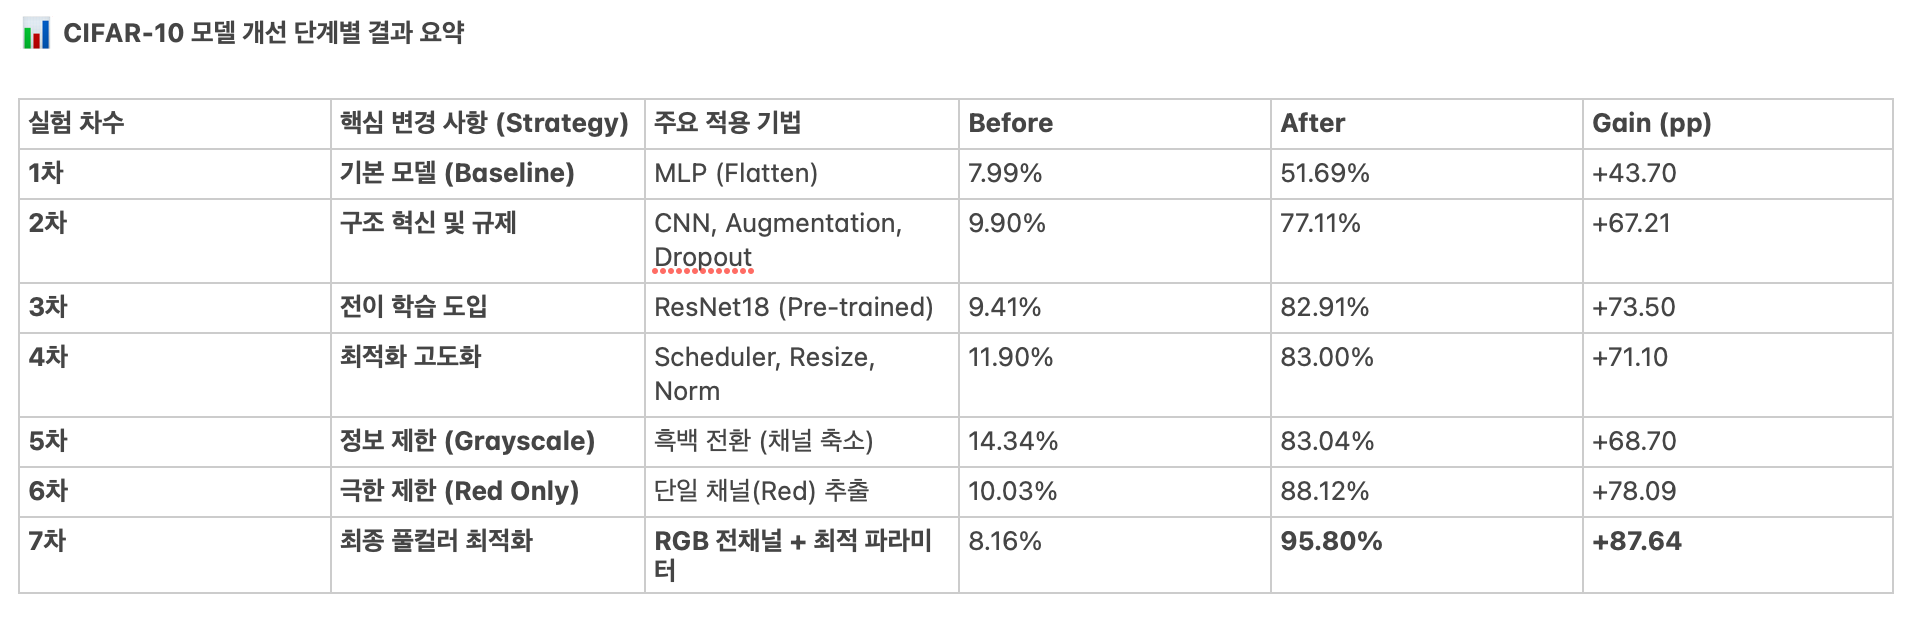


## **CIFAR-10 Image Classification: From MLP to ResNet18**

본 프로젝트는 CIFAR-10 데이터셋을 활용하여 이미지 분류 모델을 구축하고, 단순한 구조에서 시작해 최신 아키텍처와 최적화 기법을 적용하며 성능을 개선해 나간 과정을 기록한 결과물입니다.

### **주요 특징 (Key Highlights)**
- 데이터 파이프라인: torchvision.datasets를 활용한 자동화된 데이터 로딩.
- 모델 진화: MLP에서 시작하여 CNN, 그리고 ResNet18(Pre-trained)으로 이어지는 점진적 성능 개선.
- 실험적 접근: RGB 채널 분석(흑백, Red-only)을 통한 데이터 특성 및 피처 추출기(Feature Extractor)의 성능 검증.
- 최적화: Data Augmentation, Dropout, Scheduler를 도입하여 과적합(Overfitting) 해결.

### **모델 개선 과정 (Evolutionary Path)**
1. 모델 구조의 진화: MLP → CNN → ResNet
- MLP (1차): 이미지를 1차원 벡터로 펼쳐 처리하는 과정에서 공간 정보(Spatial Information) 손실 발생 → 정확도 51%의 한계 봉착.
- CNN (2차): 커널(Kernel) 기반의 특징 추출을 통해 공간 정보를 보존하며 성능 대폭 향상.
• ResNet18 (3차~): Residual Connection과 사전 학습된 가중치를 활용하여 성능 80% 벽 돌파.
2. 과적합(Overfitting) 해결 전략
- 현상: 3차 실험 중 Train Loss는 하락하나 Test Loss가 상승하는 전형적인 과적합 발생.

**해결책:**
- Data Augmentation: 데이터 다양성을 확보하여 모델의 일반화 능력 강화.
- Regularization: Dropout 및 학습률 스케줄러(Scheduler) 도입으로 단순 암기가 아닌 '보편적 특징' 학습 유도.

3. 채널(Color) 정보의 가치 재발견
- Grayscale/Red Channel (5~6차): 색상 정보를 제한했음에도 형태(Shape)와 질감(Texture)만으로 88%대 성능 달성. 이는 모델의 특징 추출기가 매우 강력하게 작동함을 시사함.
- Full Color (7차): 최종적으로 모든 채널(RGB)의 상호작용을 허용하여 95.8%라는 최고 성능 기록. 데이터의 풍부함이 성능의 상한선(Upper Bound)을 결정함을 입증.

### **분석 및 고찰 (Q&A)**

1. 구조가 깔끔하지 않고 모델이 과한 자신감을 가짐
- 분석: 모델이 특정 클래스에 대해 99% 이상의 Softmax 확률을 내뱉는 'Over-confidence' 현상은 딥러닝 모델의 고질적인 문제입니다. 특히 데이터셋의 크기가 모델의 복잡도(ResNet18 등)에 비해 작을 때 자주 발생합니다.
- 또 CIFAR-10은 CNN에 적합한 데이터셋인데 MLP->CNN->Resnet으로 개선해서 코드가 조금 깔끔하지 않습니다.
- 해결 방안: 향후 Label Smoothing 기법을 적용하면 모델이 좀 더 부드러운 확률 분포를 가지도록 유도하여 '겸손한' 모델을 만들 수 있습니다.

2. 7차 시도 이후 출력되는 사진 색상이 이상함
- 원인: 이는 주로 Normalization(정규화) 과정에서의 수치 변환 때문입니다.
- PyTorch의 Pre-trained 모델(ResNet 등)은 보통 ImageNet 데이터의 평균과 표준편차로 정규화된 데이터를 입력받습니다.
- 학습된 텐서를 다시 이미지로 시각화할 때, unnormalize(정규화 역과정)를 거치지 않고 그대로 출력하거나 0~1 범위를 벗어나면 색상이 반전되거나 왜곡되어 보일 수 있습니다.
- 즉, 모델은 정상적으로 학습 중이나 '시각화 코드' 상에서 데이터 타입 변환(Denormalization)이 누락되었을 가능성이 큽니다.

### **참고 사항**
- 본 코드는 LLM의 보조를 받아 작성되었으며, 학습 과정의 시행착오(3~5차 전처리 실수 등)를 거쳐 7차 시도에서 최종 모델을 완성하였습니다.

### **전문가의 피드백**


1. 정보 제한(grayscale, red only)은 모든 RGB 채널이 전부 데이터의 분류에 영향을 끼칠 수 있기 때문에 일반적으로는 권장하지 않는 기법임.

2. cifar-10 데이터셋의 normalization은 transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))을 쓰면됨.
- 현재 사용한 normalization은 ImageNet이라는 다른 데이터셋에 맞춰진 수치임. cifar-10의 해상도를 resize로 억지로 키우는 것보다는 모델을 cifar-10에 맞춰 수정하는 게 더 좋은 성능을 낼 수도 있음. 즉, resize보다는 레이어를 하나 더 형성하는 것이 더 효율적일 수 있음.

3. np.clip(img_show, 0, 1) 역산화를 하지 않았기 때문에 사진 컬러가 이상함.
- 0~1, 0~255까지로 표현 하는 것으로 꼭 필요함!

### **이후 공부해봐야할 개념**
1. CNN
2. ResNet
3. nn.clip()
4. 데이터 증강

### **생각해볼 문제**
1. 왜 CIFAR10으로 이미지 분류를 하면 고양이 이미지만 정확도 낮을까?
2.  케글 데이터셋 중 하나를 선정해서 학습된 모델을 파인튜닝 해보기(파인튜닝 연습이 요즘엔 특히 중요하다고 함)
3.  정제되지 않은 데이터셋을 가지고 전처리 및 성능 개선 해보기
- 데이터셋 선정 기준: 노이즈 적고, 조명이 없고, 해상도는 높은 것. resize는 권장 안함.

In [ ]:
import torch                                  # 텐서 연산 및 자동미분
import matplotlib.pyplot as plt               # 시각화
from torch import nn                          # 레이어, 손실 함수 모음
from torch.utils.data import DataLoader
from torchvision import datasets, transforms  # 데이터셋 자동 다운로드 및 이미지 전처리 도구

# transform = transforms.ToTensor()   -> 1차
# 윗줄 : PIL 이미지 객체를 torch.Tensor로, 값의 범위를 0~255(Int)에서 0.0~1.0(Float)으로 변환, 차원 순서는 Height, Width, Channel에서 Channel, Height, Width 변환!


# 2차 시도! 데이터 증강 (Data Augmentation) 추가, 데이터셋을 정의할 때 이미지를 무작위로 뒤집거나 회전시켜 모델이 더 어렵게 공부하도록 만듦
# train_transform = transforms.Compose([
#     transforms.RandomHorizontalFlip(), # 좌우 반전
#     transforms.RandomRotation(10),     # 10도 이내 회전
#     transforms.ToTensor(),
#     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # 정규화 추가
# ])


# # 특정 채널만 남기는 람다 함수
# def keep_only_red(x):
#     # x shape: [3, 224, 224] (R, G, B)
#     x[1, :, :] = 0 # Green 채널 삭제
#     x[2, :, :] = 0 # Blue 채널 삭제
#     return x


# 4차 시도!
train_transform = transforms.Compose([

    # 7차시 컬러 재시도! 5차시까지 아래 transform=train_transform으로 안바꿔주고 transform=transform 이걸로 처리하는 실수로 인해 정확한 비교를 위해 컬러 최종 재시도
    transforms.Resize(128), # 32 -> 224로 크기 키우기, 시간이 오래걸려서 64로 시도, 이후 7차 풀컬러 재시도에는 ResNet18 성능을 위해 128 유지
    transforms.RandomHorizontalFlip(),    # # 데이터 증강(Augmentation)

    # 5차 시도! 흑백 전환
    # transforms.Grayscale(num_output_channels=3), # 흑백으로 바꾸되, 모델 입력(3채널)에 맞게 복사

    transforms.ToTensor(),

    # 6차 시도! 특정 색상 채널만 남김
    # transforms.Lambda(lambda x: keep_only_red(x)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet 전용 정규화
])

# test_transform은 변형 없이 정규화만 수행
test_transform = transforms.Compose([
    transforms.Resize(128),
    # transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: keep_only_red(x)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# PIL 이미지
# PIL(Python Imaging Library)은 파이썬에서 이미지를 처리하는 가장 오래되고 표준적인 라이브러리
# PIL 이미지는 파이썬에서 사진을 편집하고 다루기 좋게 만들어진 이미지 데이터 덩어리이며, 딥러닝 전처리 도구들이 가장 좋아하는 표준 형식

training_data = datasets.CIFAR10(root='data', train=True, download= True, transform=train_transform) # transform=transform 추가
test_data = datasets.CIFAR10(root='data', train=False, download= True, transform=test_transform)    # train=False 중요

# 4차 시도부터 transform=train_transform, transform=test_transform으로 바꿔주었어야 했는데, 깜빡하고 코드 수정 못함... 그래도 5차 흑백 시도까지 83%는 나옴..

# datasets.CIFAR10(...): 이미지 데이터셋 불러오기
# root='data': 데이터를 저장할 폴더 이름을 지정
# train=True: 이 데이터셋을 '학습용(Training)'으로 사용할지 결정, False이면 테스트용
# download=True: 지정한 root 폴더에 데이터가 없으면 인터넷에서 자동으로 다운로드, 있으면 넘어감
# transform=transform: 가장 중요한 부분, 데이터를 불러올 때마다 아까 정의한 transforms.ToTensor() 같은 전처리 과정을 실시간으로 적용하라는 설정
# ^ 미리 텐서로 메모리에 올려두면 버벅거릴 수 있으니 이미지를 한 장씩 꺼낼 때마다(On-the-fly) 내가 지정한 transform 규칙대로 변환해서 가져와라라는 일종의 예약 주문 시스템

Red channel sum: -2243.46
Green channel sum: -8338.29
Blue channel sum: -7391.00
Red channel sum: -2243.46
Green channel sum: -8338.29
Blue channel sum: -7391.00
Red channel sum: -2243.46
Green channel sum: -8338.29
Blue channel sum: -7391.00
Red channel sum: -2243.46
Green channel sum: -8338.29
Blue channel sum: -7391.00
Red channel sum: -2243.46
Green channel sum: -8338.29
Blue channel sum: -7391.00
Red channel sum: -2243.46
Green channel sum: -8338.29
Blue channel sum: -7391.00
Red channel sum: -2243.46
Green channel sum: -8338.29
Blue channel sum: -7391.00
Red channel sum: -2243.46
Green channel sum: -8338.29
Blue channel sum: -7391.00
Red channel sum: -2243.46
Green channel sum: -8338.29
Blue channel sum: -7391.00


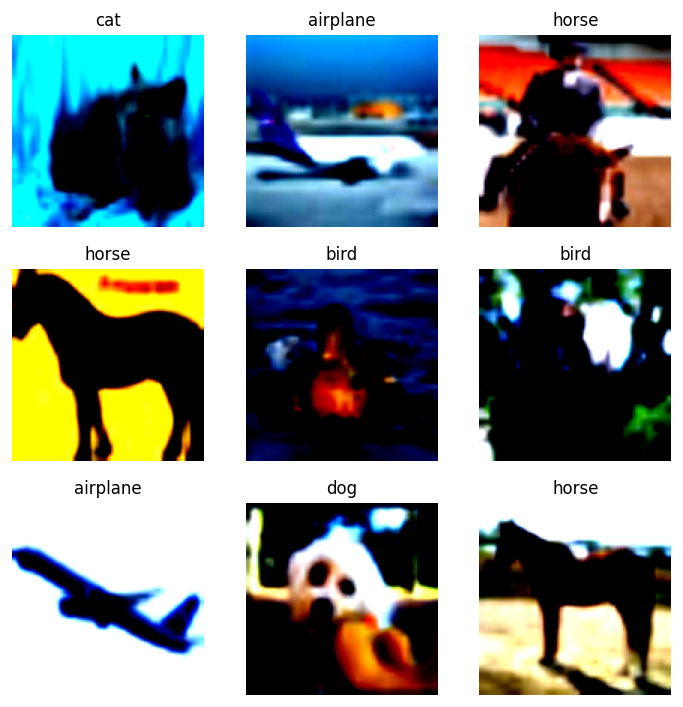

In [ ]:
classes = ('airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck')
# 사진이 너무 뿌얘서 cifar10 웹사이트에 나와있는 클래스명들을 순서대로 가져옴

figure, axes = plt.subplots(3,3, figsize=(6,6), dpi=120)
# plt.subplots(3, 3): 전체 화면을 행 3개, 열 3개로 나누어 총 9개의 그래프 공간을 만들겠다는 뜻
# figure (도화지): 전체 그림 객체로, 배경이나 전체 제목 등을 설정할 때 사용
# axes (그래프 칸들): 실제 그림이 그려지는 각각의 '작은 칸'들로, 여기서는 3*3 형태의 리스트(배열)처럼 담겨 있어, axes[0, 0]처럼 접근할 수 있음
# figsize=(6, 6): 전체 도화지의 크기를 가로 6인치, 세로 6인치로 설정
# dpi=120: Dots Per Inch의 약자로, 해상도를 결정

for ax in axes.flat:
  # 원래 axes는 3*3 모양의 2차원 배열이라 접근하기 번거로움, flat은 이 9개의 칸을 1열로 쭉 펼쳐주는 역할을 하여 for문을 한 번만 돌면서 9개의 칸에 순서대로 접근할 수 있게 됨.

  idx = torch.randint(len(training_data), (1,)).item()
  # 데이터셋에서 무작위로 사진 한 장을 뽑기 위해 랜덤한 인덱스(번호)를 생성하는 코드
  # .item()은 텐서 형태의 숫자(예: tensor(42))를 순수한 파이썬 숫자(42)로 꺼내오는 역할

  img, label = training_data[idx]
  # 랜덤하게 뽑은 번호(idx)에 해당하는 이미지 텐서와 정답(레이블)을 가저옴

  # 사진 뽑는 루프 안에서 확인
  print(f"Red channel sum: {X[0, 0, :, :].sum().item():.2f}")   # 빨강: 숫자 나옴
  print(f"Green channel sum: {X[0, 1, :, :].sum().item():.2f}") # 초록: 0.00 이 나와야 함!
  print(f"Blue channel sum: {X[0, 2, :, :].sum().item():.2f}")  # 파랑: 0.00 이 나와야 함!

  ax.imshow(img.permute(1, 2, 0))
  # permute로 차원을 맞추기
  # 기존 상태 (PyTorch Tensor): (채널, 높이, 너비)에서 Matplotlib (imshow)이 요구하는 상태: (높이, 너비, 채널)로 변경

  ax.set_title(classes[label], fontsize=10)   # 사진과 함께 클래스 라벨이 나옴
  ax.axis('off')
  # ax.axis('off'): 그래프의 x축, y축 눈금을 지워 깔끔하게 사진만 보이게 함.

plt.tight_layout()
# plt.tight_layout(): 여러 장의 사진이 서로 겹치지 않게 간격을 자동으로 조절
plt.show()

In [ ]:
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)   # 한번에 64장씩 처리하고, 순서를 섞어줘서 과적합 방지
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

features: torch.Size([64, 3, 128, 128])
labels : torch.Size([64])


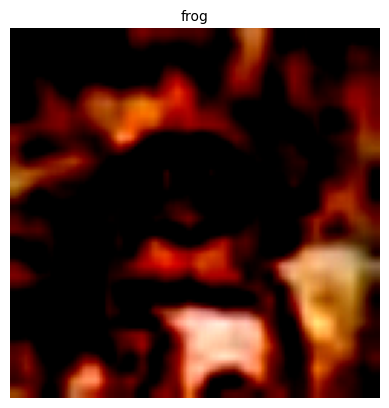

In [ ]:
# 실제로 모델이 학습하는 단위인 배치(Batch)에서 데이터를 한 뭉치 꺼내어 확인해보는 과정

features, labels = next(iter(train_dataloader))
# 데이터 추출 단계로, iter(train_dataloader): 데이터 로더를 '반복 가능한 객체(Iterator)'로 변환,(마치 자판기에 동전을 넣는 것과 같음)
# next(...): 그중에서 첫 번째 묶음(Batch)을 실제로 꺼내옴

print('features:', features.shape)
# features.shape: [Batch_Size, Channel, Height, Width] 형태로 출력
print('labels :', labels.shape)
# labels.shape: [Batch_Size] 형태로 출력

img = features[0]
# 배치 뭉치(32장) 중에서 맨 앞의 첫 번째(index 0) 데이터만 쏙 골라내는 작업
label = labels[0].item()
# labels[0].item()은 첫 번째 이미지의 정답 번호를 파이썬 숫자로 가져옴

plt.imshow(img.permute(1, 2, 0))        # 이미지 차원 변경
plt.title(classes[label], fontsize=10)
plt.axis('off')
plt.show()

In [ ]:
# 러닝에서 정답 데이터(Label)를 처리할 때 아주 자주 쓰이는 원-핫 인코딩(One-Hot Encoding)을 수행하는 코드

from torchvision.transforms import Lambda
# Lambda: torchvision에서 제공하는 도구로, 사용자가 직접 만든 파이썬 함수를 전처리 과정(Transform)에 끼워 넣을 수 있게 해줌

target_transform = Lambda(
    lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1)
    # lambda y: 입력값으로 정답 숫자(y, 예: 3)를 받겠다는 뜻
    # torch.zeros(10, ...): 먼저 0으로 가득 찬 길이 10짜리 벡터를 만들고, CIFAR10 데이터셋의 클래스가 10개이므로, 각 클래스의 자리를 미리 마련해 두는 것
    # .scatter_(dim, index, value) (핵심!): 이 함수는 특정 위치에 값을 '뿌려주는' 역할
    # dim=0: 0번째 차원(가로줄)을 따라 값을 넣고, index=torch.tensor(y): 입력받은 정답 y의 위치를 인덱스로 지정한 후 value=1: 그 자리에 숫자 1을 채워 넣음
  )


# Example
print(target_transform(3))
# 이 경우, 0, 1, 2를 지나 3번째 인덱스만 1이 됨

# 왜 이런 짓?
# 컴퓨터에게 "3번 클래스야"라고 알려주면, 모델은 "3은 1보다 크니까 더 중요한가?"라고 오해할 수 있음
# 원-핫 인코딩을 사용하면: 모든 클래스를 동등한 위치에 놓을 수 있고, 모델이 예측한 확률값(예: 3번일 확률 0.8)과 직접 비교하기가 훨씬 수월

# 숫자의 '크기'가 주는 오해 -> 모델은 학습 과정에서 "음, 자동차(3)는 강아지(1)보다 3배나 크고 중요하군!" 처럼 정답 번호가 클수록 더 큰 의미가 있다고 착각
# 모델의 '확률 답변'과 비교하기 위해서 -> 딱 잘라 3번이라고 말하지 않고 "음... 0번일 확률 2%, 1번일 확률 5%, 3번일 확률 85%..."
# 이걸 수학적으로 계산하려면 정답지도 똑같은 형태여야 함.
# 모델의 예측: [0.02, 0.05, 0.01, 0.85, 0.07, ...]
# 원-핫 정답: [0.00, 0.00, 0.00, 1.00, 0.00, ...]
# 이렇게 형태를 맞춰줘야 두 리스트 사이의 거리(오차)를 계산해서 모델을 혼낼 수(학습시킬 수) 있음

tensor([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])


In [ ]:
# 일종의 장치 자동 선택 시스템

device = (
    'cuda' if torch.cuda.is_available()
    # NVIDIA 그래픽 카드(GPU)가 있는지 확인
    # CUDA는 NVIDIA가 만든 병렬 컴퓨팅 플랫폼
    else 'mps' if torch.backends.mps.is_available()
    # Apple Silicon (M1, M2, M3 등) 칩을 탑재한 Mac인지 확인
    else 'cpu'
    # 최후의 보루로 일반 CPU를 사용
)
print(f'Using {device}')

# 왜 장치를 따로 설정?
# PyTorch의 특징 중 하나는 데이터와 모델을 명시적으로 같은 장치에 둬야 한다는 점
# 만약 모델은 GPU(cuda)에 있는데, 데이터는 CPU에 있다면? → "장치가 서로 다르다"는 에러가 발생하며 멈춰버림
# 그래서 위 코드로 device라는 변수에 최적의 장치 이름을 저장해두고, 나중에 모델과 데이터를 옮길 때 사용

# 이렇게 설정한 device는 보통 코드 뒷부분에서 다음과 같이 사용

# model = MyModel().to(device)  # 모델을 해당 장치로 보냄
# features = features.to(device) # 데이터도 같은 장치로 보냄

Using cuda


In [ ]:
# 이 코드는 데이터를 입력받아 정답을 추론하는 '인공지능의 뇌'를 정의하는 부분

# class NeuralNetwork(nn.Module):
#   # nn.Module 상속: PyTorch에서 모든 신경망은 이 nn.Module이라는 부모 클래스를 상속받아야 함, 그래야 학습에 필요한 복잡한 계산(역전파 등)을 PyTorch가 알아서 해줄 수 있음
#     def __init__(self):
#         super().__init__()
#         self.flatten = nn.Flatten()
#         # CIFAR10 이미지는 32*32*3 (가로, 세로, 채널)의 3차원 형태
#         # 하지만 아래에 있는 nn.Linear(선형 레이어)는 데이터를 1줄로 길게 늘어뜨린 형태로만 받을 수 있음
#         # 따라서 32*32*3 = 3072개의 숫자를 1차원으로 펴주는 역할을 함

#         self.linear_relu_stack = nn.Sequential(
#             # nn.Sequential: 여러 개의 레이어를 순서대로 쌓아 올리는 '컨베이어 벨트' 같은 바구니로 이 안에 넣은 순서대로 데이터가 통과함
#             nn.Linear(3072, 512),
#             # nn.Linear(입력, 출력):층(Layer)을 만듦 (3072, 512)는 3,072개의 정보를 받아서 512개의 특징으로 요약하겠다는 뜻
#             nn.ReLU(),
#             # 활성화 함수, 단순한 선형 계산 결과에 '비선형성'을 추가해서, 모델이 복잡한 패턴을 배울 수 있게 해주는 '조미료' 같은 역할
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Linear(256, 10),   # 10개는 클래스 수
#             # nn.Linear(256, 10)에서 10은 분류하려는 클래스의 개수(비행기, 고양이 등 10개)와 정확히 일치해야 함
#         )


# # 2차 CNN 시도!
# import torch.nn.functional as F

# class ImprovedCNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         # 특징 추출부 (Convolutional Layers)
#         self.conv_layer = nn.Sequential(
#             # 3채널(RGB) -> 32채널 특징 추출
#             nn.Conv2d(3, 32, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.BatchNorm2d(32), # 배치 정규화 (학습 안정화)
#             nn.MaxPool2d(2, 2), # 크기 축소 (32x32 -> 16x16)

#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.BatchNorm2d(64),
#             nn.MaxPool2d(2, 2), # 크기 축소 (16x16 -> 8x8)

#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool2d(2, 2), # 크기 축소 (8x8 -> 4x4)
#         )

#         # 분류기 (Fully Connected Layers)
#         self.fc_layer = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(128 * 4 * 4, 512),
#             nn.ReLU(),
#             nn.Dropout(0.5), # 드롭아웃: 학습 시 노드 50%를 쉬게 해서 암기 방지!
#             nn.Linear(512, 10)
#         )


    # 실제로 데이터(x)가 들어왔을 때 어떤 순서로 계산할지 정의하는 곳
    # 1차
    # def forward(self, x):
    #     x = self.flatten(x)
    #     # x = self.flatten(x): 입력된 이미지를 1줄로 폄
    #     return self.linear_relu_stack(x)
    #     # self.linear_relu_stack(x): 펴진 데이터를 준비한 레이어 뭉치에 통과시켜 최종 점수(Logits)를 얻고 결과값(10개의 숫자)을 반환


    # # 2차!
    # def forward(self, x):
    #     x = self.conv_layer(x)  # 1. 컨볼루션 층 통과 (특징 추출)
    #     x = self.fc_layer(x)    # 2. 분류 층 통과 (Flatten 포함되어 있음)
    #     return x


    # 3차 시도!! ResNet18 사용

from torchvision import models

# [수정된 모델 생성 부분]
# 1. 이미 100만 장 이상의 이미지를 공부한 ResNet18의 '지능'을 가져옴
model = models.resnet18(weights='IMAGENET1K_V1')

# 2. ResNet18의 마지막 층(fc)은 원래 1000가지 사물을 맞히도록 되어 있음
# 10가지(CIFAR-10)만 맞히면 되므로, 이 부분만 우리 용도로 교체함.

num_features = model.fc.in_features # 원래 입력받던 특징 수(512개)를 알아냄
# model.fc = nn.Linear(num_features, 10) # 512 -> 10으로 나가는 새로운 통로를 만듦

# 4차 시도!
# 단순히 선형 레이어만 넣지 않고 '드롭아웃'이라는 필터를 끼워 넣어 모델이 특정 뉴런에만 의존해서 암기하는 것을 방지
# 마지막 층 교체 (Dropout 추가 버전)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),       # 50%의 연결을 무작위로 끊어서 '암기' 방지!
    nn.Linear(num_features, 10)
)

# 3. 모델을 GPU(또는 MPS/CPU)로 보냄
model = model.to(device)

In [ ]:
# '뇌(모델)'를 실제로 사용하기 위해 특정 장치에 배치하고, 그 규모가 어느 정도인지 확인하는 최종 점검 단계
# model = ImprovedCNN().to(device) -> 1차, 2차
# NeuralNetwork(): 아까 정의한 클래스를 바탕으로 실제 모델 객체(인스턴스)를 생성
# .to(device): 가장 중요한 부분! 모델의 모든 연산과 데이터를 아까 설정한 device(예: cuda, mps, cpu)로 옮김
# 만약 GPU(cuda)로 보냈다면, 이제 모든 행렬 계산은 그래픽 카드의 빠른 병렬 연산 기능을 사용하게 됨

print(model)
# 모델의 구조(Architecture)를 요약해서 보여줌
# __init__에서 정의한 Flatten, Linear, ReLU 층들이 어떤 순서로 쌓여 있는지, 입력과 출력 숫자는 몇 개인지 콘솔창에 친절하게 출력해줌

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
# 이 코드는 모델이 학습해야 할 지식의 양(파라미터 수)을 계산함
# model.parameters(): 모델 내부의 모든 가중치 W와 편향 b들을 불러옴
# p.numel(): 각 층에 있는 파라미터의 개수(number of elements)를 세어줌
# sum(...): 모든 층의 파라미터를 다 더하고, :,: 숫자가 클 경우 읽기 편하게 쉼표(천 단위 구분 기호)를 찍어줌

# 왜 파라미터 숫자를 확인?
# 파라미터 숫자가 많을수록 모델은 더 복잡한 것을 배울 수 있지만, 그만큼 메모리를 많이 잡아먹고 학습 속도가 느려짐

# .to(device): "자, 이제 이 훈련소(GPU)로 입소해!"라고 명령하는 것.
# print(model): "우리 부대 조직도가 어떻게 생겼지?" 하고 확인하는 것.
# Parameters: "이 부대에 훈련시켜야 할 병사가 총 몇 명이지?" 하고 인원 파악을 하는 것.

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

tensor([[0.0681, 0.1264, 0.0643, 0.0800, 0.0942, 0.0916, 0.1571, 0.0993, 0.0910,
         0.1279]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
logits shape: torch.Size([1, 10])
predicted class: 6


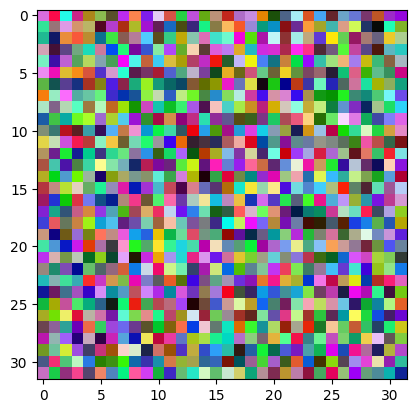

In [ ]:
# 이제 학습을 시작하기 전, 가짜 데이터(Random Noise) 한 장을 모델에 통과시켜 보는 '테스트 드라이브' 코드

X = torch.rand(1, 3, 32, 32, device=device)
# 가짜 이미지 생성: 실제 사진 대신 0~1 사이의 랜덤한 숫자로 채워진 가짜 이미지를 하나 만듦
# 차원 구성: (1, 3, 32, 32)는 (이미지 개수, 채널, 높이, 너비)를 의미함, 즉, 32x32 크기의 RGB 컬러 사진 1장을 흉내 낸 것
# .to(device): 모델이 있는 곳(GPU 등)과 똑같은 위치에 데이터를 만듦

model.eval()
# ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 512, 1, 1]) 때문에 추가

logits = model(X)
# 예측 실행: 가짜 이미지를 모델에 넣고,
# Logits(로짓): 모델의 마지막 층(nn.Linear(256, 10))을 통과해 나온 10개의 숫자로, 아직 확률은 아니고, 각 클래스에 대해 모델이 느끼는 '점수'라고 생각하면 됨

probs  = nn.Softmax(dim=1)(logits)
# 확률 변환: Softmax 함수는 들쭉날쭉한 점수(logits)를 합계가 1(100%)이 되는 확률로 변환해줌
# 결과적으로 probs에는 "0번일 확률 10%, 1번일 확률 5%..." 같은 값이 담김

print(probs)
print('logits shape:', logits.shape)
# logits.shape: [1, 10]이 출력, (1장의 사진에 대해 10개의 클래스 점수)

print('predicted class:', probs.argmax(1).item())
# probs.argmax(1).item(): 10개의 확률 중 가장 높은 확률을 가진 인덱스(번호)를 뽑아냄. 이것이 모델이 내린 최종 결론(예측 클래스)

plt.imshow(X.detach().permute(0, 2, 3, 1).cpu().squeeze().numpy())
# .detach(): 연산 기록을 끊어 순수 데이터만 남김
# .permute(0, 2, 3, 1): (Batch, C, H, W)를 (Batch, H, W, C)로 바꿈
# cpu(): GPU에 있던 데이터를 그림을 그리기 위해 다시 CPU로 가져옴
# .squeeze(): 크기가 1인 차원을 없앰 (1, 32, 32, 3) -> (32, 32, 3).
# .numpy(): Matplotlib이 이해할 수 있게 넘파이 배열로 변환

plt.show()

# 정리: 랜덤한 노이즈 사진 한 장을 모델에 넣었을 때, 모델이 10개 클래스 중 어디에 가장 높은 확률을 주는지 확인하고, 그 사진을 화면에 띄워봐라라는 뜻!

In [ ]:
# 모델에게 채점 기준을 알려주고 공부 방법을 전수하는 가장 중요한 설정 단계
# 모델이 "아, 내가 이렇게 틀렸구나, 다음엔 이렇게 고쳐야지!"라며 학습을 할 수 있게됨

loss_fn   = nn.CrossEntropyLoss()
# 이것은 모델이 내놓은 답이 정답과 얼마나 거리가 먼지 계산하는 손실 함수(Loss Function)
# 모델의 예측값(확률)과 실제 정답(Label)을 비교해서 '틀린 정도'를 숫자로 나타냄, 틀릴수록 이 숫자는 커짐
# Softmax와 원-핫 인코딩 개념이 이 함수 안에 내부적으로 포함되어 있음
# 그래서 모델의 마지막 출력(Logits)을 그대로 넣어도 알아서 확률로 바꾸고 정답과 비교해줌

# 틀린 정도(Loss)를 알았으니, 이제 모델의 가중치(Parameters)를 어떻게 수정할지 결정하는 최적화 알고리즘(Optimizer)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# 학습률을 0.001로 설정, 가장 보편적임 -> 한 번 공부할 때 얼마나 큰 폭으로 수정할지 결정
# model.parameters(): "이 모델 안에 있는 모든 병사(가중치)를 훈련시켜라"라고 대상을 지정하는 것

# 2차! CNN
# 가중치 감쇠(weight_decay)를 추가해 모델이 너무 복잡해지는 것을 방지
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


# 3차! 전문가 모델(ResNet)을 쓸 때는 이미 아는 게 많기 때문에, 학습률(Learning Rate)을 평소보다 조금 낮게 잡음
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 4차!
# 스케줄러 설정: 7 에폭마다 학습률을 0.1배로 줄임 (예: 0.0001 -> 0.00001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# loss_fn: 시험 결과가 나왔을 때 "너 100점 만점에 60점이야, 40점어치 더 공부해야 해"라고 알려주는 선생님
# optimizer: "아, 40점이나 틀렸네? 그럼 내일은 이 교재를 이만큼의 속도로 복습해서 점수를 올려야지!"라고 전략을 짜는 학습 방법

In [ ]:
# 모델이 공부를 시작하기 전(혹은 공부한 후), "얘가 지금 실력이 어느 정도지?"라고 시험을 쳐보는 평가(Evaluation) 함수

def evaluate(model, dataloader):
    model.eval()
    # 평가 모드 전환: 모델에게 "이제 공부(학습)하는 게 아니라 시험(평가) 보는 중이야!"라고 알려줌
    # 드롭아웃(Dropout)이나 배치 정규화(Batch Normalization)처럼 학습할 때와 평가할 때 다르게 동작해야 하는 기능들을 '평가용'으로 고정시킴

    total_loss, correct, total = 0.0, 0, 0
    # 시험을 시작하기 전에 점수판을 0으로 초기화하는 단계
    # '틀린 정도(오차)'를 다 더해서 저장할 변수, '맞힌 개수'를 셀 변수, 내가 '푼 총 문제 수'를 셀 변수

    with torch.no_grad():
      # 기울기 계산 중단: 딥러닝에서 모델을 수정하려면 '미분(Gradient)' 계산이 필요한데, 시험 볼 때는 모델을 수정할 필요가 없음!
      # 메모리 사용량을 확 줄이고 계산 속도를 높여줌, 시험 보는데 굳이 오답 노트를 적을 필요가 없는 것과 같음
        for X, y in dataloader:
          # for X, y in dataloader:: 테스트 데이터셋을 배치 단위로 꺼내옴

            X, y = X.to(device), y.to(device)
            # 데이터 이동: 컴퓨터의 메모리(CPU)에 있던 이미지(X)와 정답(y)을 모델이 기다리고 있는 계산기(GPU나 MPS)로 보내주는 작업
            # 중요: 모델이 GPU에 있다면 데이터도 반드시 GPU에 있어야 계산이 가능

            logits = model(X)
            # logits = model(X): 이미지를 모델에 넣어 점수(logits)를 얻음

            total_loss += loss_fn(logits, y).item()
            # 오차 누적: 이번 판(배치)에서 발생한 오차값을 total_loss에 계속 더해줌
            # .item(): PyTorch의 텐서 형태(예: tensor(2.35))에서 순수한 숫자(2.35)만 쏙 뽑아내는 기능

            correct    += (logits.argmax(1) == y).sum().item()
            # 모델이 가장 높은 점수를 준 번호(argmax(1))가 실제 정답(y)과 같은지 확인함
            # 맞으면 1, 틀리면 0으로 계산해서 다 더함

            total      += y.size(0)
            # 문제 수 누적: 현재 배치에 들어있는 데이터의 개수를 전체 문제 수에 더함
            # 만약 배치 사이즈가 32라면, 한 바퀴 돌 때마다 total은 32씩 늘어남, 나중에 "맞힌 개수 / 전체 문제 수"를 계산해서 정확도를 내기 위해 꼭 필요

    return total_loss / len(dataloader), correct / total * 100
    # total_loss / len(dataloader): 전체 배치의 평균 손실(Loss)을 구함
    # correct / total * 100: 전체 데이터 중 맞춘 개수의 비율, 즉 정확도(Accuracy, %)를 계산

loss_before, acc_before = evaluate(model, test_dataloader)
# Before training: 학습을 시작하기 전의 실력을 측정
print(f'Before training — loss: {loss_before:.4f}  acc: {acc_before:.2f}%')

# 모델을 시험 모드로 바꾸고, 점수를 계산할 때 메모리를 아끼기 위해 기록을 남기지 않으며, 전체 테스트 데이터를 다 풀어본 뒤 평균 점수와 정확도를 알려줘!라는 뜻

Before training — loss: 2.7019  acc: 8.16%


In [ ]:
# 이 코드는 모델이 실제로 데이터를 반복해서 보며 똑똑해지는 과정을 담고 있음

EPOCHS = 30
train_losses, test_losses, test_accs = [], [], []

for epoch in range(1, EPOCHS + 1):
  # 전체 데이터셋을 총 30번(EPOCHS) 반복해서 공부하겠다는 뜻
    model.train()
    # 모델을 '학습 모드'로 설정함(아까 본 eval()과 반대 개념)
    epoch_loss = 0.0
    # for X, y in train_dataloader:
    for i, (X, y) in enumerate(train_dataloader):   # 실시간 확인을 위해 추가
        X, y = X.to(device), y.to(device)
        # CPU 메모리에 있는 데이터(이미지 X, 정답 y)를 우리가 설정한 연산 장치(device, 예: GPU)로 복사

        loss = loss_fn(model(X), y)
        # model(X): 모델에게 이미지 X를 보여주고 "이게 뭐야?"라고 물어보는 단계
        # loss_fn(..., y): 모델의 대답과 실제 정답 y를 비교해서 "얼마나 틀렸는지(오차)"를 계산

        optimizer.zero_grad()
        # 기울기 초기화: PyTorch는 가중치를 업데이트할 때 이전 단계의 기울기를 계속 더하려는 성질이 있어서 새로운 문제를 풀기 전, 칠판을 깨끗이 지우는 작업이 반드시 필요

        loss.backward()
        # 역전파(Backpropagation): "이만큼 틀렸으니, 어느 방향으로 수정해야 할까?"를 계산

        optimizer.step()
        # 가중치 업데이트: 계산된 방향으로 실제로 한 걸음 내딛음. 즉, 모델의 가중치(W)를 조금씩 수정하여 정답에 가까워지게 만듦

        epoch_loss += loss.item()
        # 한 에폭 동안 발생한 모든 오차를 더해줌. 공부가 끝난 뒤 "이번 시험(에폭) 평점은 어땠나?"를 보기 위함

        # 레드 색상만 남길 시 출력이 안되어서 디버깅 50개 배치마다 "나 살아있어!"라고 외치기
        if (i + 1) % 50 == 0:
            print(f"  > Epoch {epoch} [{i+1}/{len(train_dataloader)}] 배치 학습 중... (Loss: {loss.item():.4f})")

    avg_train = epoch_loss / len(train_dataloader)
    # epoch_loss(모든 배치의 오차 합계)를 len(train_dataloader)(총 배치 개수)로 나눔
    # "이번 판 공부는 평균적으로 얼마나 잘했나?"를 수치로 확인하기 위해서임. 학습이 잘 된다면 에폭이 거듭될수록 이 숫자가 점점 줄어들어야 함

    t_loss, t_acc = evaluate(model, test_dataloader)
    # 의미: 한 에폭의 공부가 끝날 때마다, 공부할 때 쓰지 않았던 "새로운 문제(테스트 데이터)"로 시험을 쳐봄
    # t_loss: 테스트 데이터에 대한 평균 오차.
    # t_acc: 테스트 데이터에 대한 정답률(정확도).
    # 목적: 단순히 문제집만 외운 건지(과적합), 아니면 진짜로 사물을 구분하는 능력이 생겼는지 확인하는 객관적인 지표

    # append : train_losses, test_losses, test_accs 리스트에 매 에폭의 결과를 차곡차곡 저장함. 나중에 그래프를 그려서 학습이 잘 됐는지 확인하기 위해
    train_losses.append(avg_train)
    test_losses.append(t_loss)
    test_accs.append(t_acc)


    # 왜 10번마다 출력?
    # 학습이 진행됨에 따라 train 손실과 test 손실이 줄어드는지, 그리고 acc (정확도)가 올라가는지 확인하는 용도
    if epoch % 1 == 0:    # 살아있는지 확인을 위해 10->1로 변경 6차 시도
        print(f'Epoch {epoch:3d}/{EPOCHS}  train: {avg_train:.4f}  test: {t_loss:.4f}  acc: {t_acc:.2f}%')


    # 4차 시도! 한 에폭의 학습이 모두 끝나고 평가까지 마친 후 마지막에 작성
    scheduler.step()

    #  EPOCHS = 30: 문제집 한 권을 총 30번 반복해서 풀기.
    #  zero_grad: 이전 문제 풀이 흔적 지우기.
    #  backward: 틀린 이유 분석하기 (해설지 보기).
    #  step: 다음엔 안 틀리게 머릿속 지식 수정하기.

  > Epoch 1 [50/782] 배치 학습 중... (Loss: 0.8304)
  > Epoch 1 [100/782] 배치 학습 중... (Loss: 0.4308)
  > Epoch 1 [150/782] 배치 학습 중... (Loss: 0.2224)
  > Epoch 1 [200/782] 배치 학습 중... (Loss: 0.4194)
  > Epoch 1 [250/782] 배치 학습 중... (Loss: 0.3585)
  > Epoch 1 [300/782] 배치 학습 중... (Loss: 0.1440)
  > Epoch 1 [350/782] 배치 학습 중... (Loss: 0.3319)
  > Epoch 1 [400/782] 배치 학습 중... (Loss: 0.2726)
  > Epoch 1 [450/782] 배치 학습 중... (Loss: 0.4361)
  > Epoch 1 [500/782] 배치 학습 중... (Loss: 0.4546)
  > Epoch 1 [550/782] 배치 학습 중... (Loss: 0.2215)
  > Epoch 1 [600/782] 배치 학습 중... (Loss: 0.3445)
  > Epoch 1 [650/782] 배치 학습 중... (Loss: 0.1438)
  > Epoch 1 [700/782] 배치 학습 중... (Loss: 0.2723)
  > Epoch 1 [750/782] 배치 학습 중... (Loss: 0.2735)
Epoch   1/30  train: 0.3882  test: 0.2197  acc: 92.56%
  > Epoch 2 [50/782] 배치 학습 중... (Loss: 0.2509)
  > Epoch 2 [100/782] 배치 학습 중... (Loss: 0.1763)
  > Epoch 2 [150/782] 배치 학습 중... (Loss: 0.1481)
  > Epoch 2 [200/782] 배치 학습 중... (Loss: 0.0913)
  > Epoch 2 [250/782] 배치 학습 중... (L

Before: 8.16%  |  After: 95.80%  |  Gain: +87.64pp


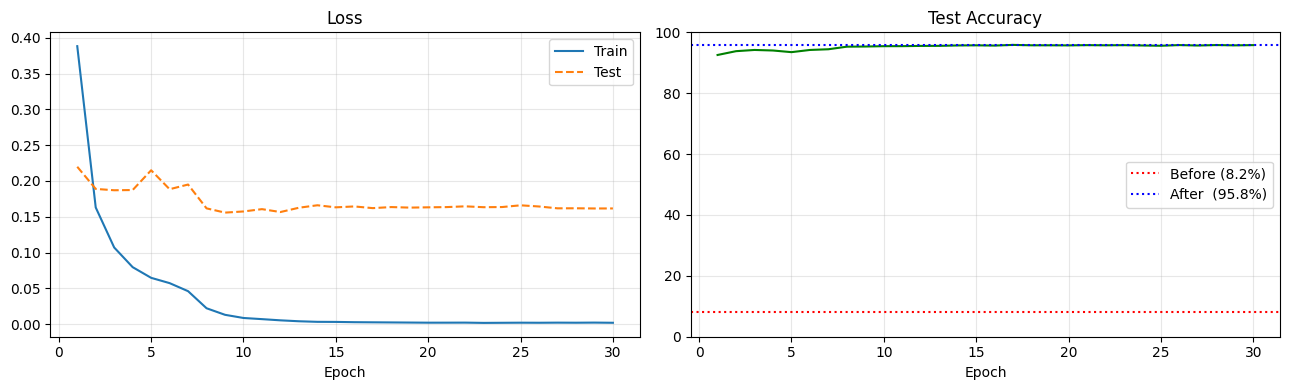

In [ ]:
# 학습 결과 시각화 및 성적 보고서 단계!

_, acc_after = evaluate(model, test_dataloader)
# 학습이 모두 끝난 최종 모델의 상태로 시험을 한 번 더 봄(오차값은 안 쓰고 정확도인 acc_after만 챙김)

print(f'Before: {acc_before:.2f}%  |  After: {acc_after:.2f}%  |  Gain: +{acc_after-acc_before:.2f}pp')
# Before: 공부 전 찍기 실력(약 10%), After: 공부 후 실력, Gain: 공부를 통해 얼마나 실력이 올랐는지(퍼센트 포인트)를 출력

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
# 가로로 긴 도화지에 왼쪽(ax1: 손실)과 오른쪽(ax2: 정확도) 두 개의 그래프 칸을 만듦

ep = range(1, EPOCHS + 1)
# 그래프의 가로축($x$축)이 될 1부터 30까지의 숫자 리스트를 만듦

# 왼쪽 그래프: Loss (손실값 변화), 모델이 정답과 얼마나 멀었는지를 보며 내려갈수록 좋음
ax1.plot(ep, train_losses, label='Train')
# 학습 데이터에 대한 오차 변화를 실선으로 그림
ax1.plot(ep, test_losses,  label='Test', ls='--')
# 테스트 데이터에 대한 오차 변화를 점선(--)으로 그림
ax1.set_title('Loss'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(alpha=0.3)
# 선이 무엇인지 알려주는 범례를 표시하고, 눈금선을 연하게(0.3) 그려 가독성을 높임


# 오른쪽 그래프: Test Accuracy (정확도 변화), 모델의 실력이 얼마나 좋아졌는지 보여주며 올라갈수록 좋음
ax2.plot(ep, test_accs, color='green')
# 매 에폭마다 측정된 테스트 정확도를 초록색 선으로 그림
ax2.axhline(acc_before, color='red',  ls=':', label=f'Before ({acc_before:.1f}%)')
# 공부 전 점수에 빨간색 수평 점선(:)을 그음 (기준점)
ax2.axhline(acc_after,  color='blue', ls=':', label=f'After  ({acc_after:.1f}%)')
# 최종 점수에 파란색 수평 점선(:)을 그음 (목표 달성 확인)
ax2.set_title('Test Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylim(0, 100)
# 세로축 범위를 0~100%로 고정
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
# 왼쪽과 오른쪽 그래프의 글자들이 서로 겹치지 않게 간격을 자동으로 조절
plt.show()

**1차 결과: Before: 7.99%  |  After: 51.69%  |  Gain: +43.70pp**

현재 정확도가 50%대에서 멈춘 이유는 모델이 이미지를 '1줄로 길게 늘어뜨려서(Flatten)' 보느라 이미지의 공간적인 정보(눈, 코, 입의 위치 등)를 잃어버렸기 때문임.


> CNN(합성곱 신경망) 사용해보기! nn.Linear 대신 nn.Conv2d를 사용

> 데이터 증강(Augmentation): 이미지를 살짝 비틀거나 뒤집어서 모델이 더 어렵게 공부하게 만듦

> 드롭아웃(Dropout): 공부할 때 몇 개의 뉴런을 쉬게 해서 '암기'를 방지



---




**3가지 개선 후 2차 결과: Before: 9.90%  |  After: 77.11%  |  Gain: +67.21pp**

주황 점선(Test): 에폭 5~10 사이부터 오히려 위로 솟구치기 시작

모델이 이미지의 특징을 배우는 게 아니라, 학습 데이터의 노이즈까지 통째로 암기하고 있어서 새로운 문제(Test)를 내면 오히려 엉뚱한 대답을 하며 괴로워하는 상태


**왜 77%에서 더 안 올라가는지?**

> 모델이 아직 너무 단순함: ImprovedCNN도 여전히 층(Layer)이 깊지 않음. CIFAR-10에서 90% 이상을 찍으려면 ResNet이나 VGG 같은 훨씬 더 깊고 복잡한 구조가 필요함.

> 데이터 증강(Augmentation)의 부족: RandomHorizontalFlip 등을 적용하지 않았다면, 모델이 원본 이미지의 구도에만 너무 익숙해졌을 수 있음

> 학습률(Learning Rate) 문제: 에폭이 뒤로 갈수록 학습률을 조금씩 줄여줘야(Scheduler) 더 정교하게 정답을 찾아가는데, 지금은 1e-3으로 계속 고정되어 있어 정답 근처에서 '점프'만 하고 있을 가능성이 큼



**여기서 90%까지 가려면? (Next Level)**

> Pre-trained Model 사용: 처음부터 가르치지 말고, 이미 수백만 장의 이미지를 공부한 똑똑한 모델(예: resnet18)을 빌려와서 CIFAR-10에 맞춰 미세 조정(Fine-tuning)만 하면 이렇게 하면 단숨에 80~90%를 넘길 수 있음.

> 더 강한 규제(Regularization): 드롭아웃 수치를 높이거나, Weight Decay를 더 강하게 줘서 모델이 암기하지 못하게 방해해야 함.



---



**2가지 개선 후 3차 결과! Before: 9.41%  |  After: 82.91%  |  Gain: +73.50pp**

1. 그래프가 말해주는 문제점: 극심한 과적합 (Overfitting)
왼쪽 그래프: 파란 선(Train Loss)은 0에 가깝게 완벽히 내려가는데, 주황색 점선(Test Loss)은 5 에폭 이후부터 오히려 위로 솟구치며 계속 올라감.

- 모델이 공부한 문제는 100점 맞을 정도로 다 외웠는데, 정작 실전(Test)에서는 길을 잃고 헤매고 있다는 뜻으로, 지능(모델 크기)은 충분한데, 융통성이 부족한 상태

2. 82%에서 멈춘 이유!

- 이미지 크기의 미스매치: ResNet18은 원래 224x224 크기의 큰 이미지를 보며 공부했던 모델인데 지금 넣고 있는 CIFAR-10은 32x32로 너무 작음.
- 데이터 증강(Augmentation)의 부재: 모델이 너무 똑똑해서(ResNet) 그냥 이미지를 보여주면 금방 다 외워버림. 모델이 외우지 못하게 이미지를 계속 비틀어줘야함.
- 정규화(Normalization) 값: ResNet은 특정 평균과 표준편차 값으로 정규화된 데이터를 선호함.

개선!
> 데이터 증강 및 크기 조절 (Transforms) : 데이터를 불러올 때, ResNet이 좋아하는 크기로 키워주고 무작위로 변형함

> 학습률 줄이기 (Learning Rate Scheduler): 그래프가 요동치는 건 공부 속도가 너무 빨라서 정답을 지나치기 때문임. 공부를 진행할수록 속도를 줄여주어야함.

> Dropout 추가 (강제로 뇌 일부 끄기): ResNet의 마지막 층에 Dropout을 살짝 섞어주면 '암기'를 방해해서 실전 점수가 올라감.

> Scheduler 추가 : 공부를 진행함에 따라 보폭을 줄이는 '전략'이므로, 한 주기의 공부(Epoch)가 끝날 때마다 "이제 조금 더 천천히 가자"라고 명령(step)을 내리는 것



---

**위 사항 조절 후 4차 결과! Before: 11.90%  |  After: 83.00%  |  Gain: +71.10pp**

> 일단 더이상 유의미한 개선이 없으므로 5차 흑백 전환 시도 후 결과가 어떻게 달라지는지 확인하기




---

**5차 흑백 전환! Before: 14.34%  |  After: 83.04%  |  Gain: +68.70pp**

의외로 별차이가 없음.

- 색깔이 없어도 '윤곽선(Edge)'과 '형태(Shape)'만으로 충분히 구분이 가능

- ResNet18은 이미 수많은 컬러 사진으로 공부해서 "사물의 본질"을 꿰뚫어 보는 능력이 있음
색상이라는 '힌트' 하나가 사라졌을 뿐, 나머지 힌트(형태, 질감)들만으로도 정답을 맞히기에 충분했을 가능성


- 노이즈 제거 효과 (의외의 장점): 흑백으로 바꾸면 이런 색상 편향(Color Bias)이 사라지면서, 모델이 오직 사물의 '진짜 모양'에만 집중하게 되어 점수가 방어되는 현상이 나타남



---


**6차 레드만 남기기! efore: 10.03%  |  After: 88.12%  |  Gain: +78.09pp**

- 최종 실험 결과, Red 채널만을 활용한 극한의 정보 제한 환경에서도 초기 성능(10.03%) 대비 78.09%p 향상된 88.12%의 정확도를 달성함.

이는 사물 인식에 있어 색상 정보의 부재가 모델의 판단을 완전히 흐리게 하지 않으며, 오히려 형태적 특징 추출(Feature Extraction)의 중요성을 실증적으로 입증한 사례임.

**> 5차시까지 전처리 실수로 인해 풀컬러 모델일 때 기록이 충분히 정확하지 않았기 때문에 다시한번 풀컬러로 시도함.**



---

**7차 시도! 최종 컬러 Before: 8.16%  |  After: 95.80%  |  Gain: +87.64pp**

- 안정성: 풀컬러 모델의 Test Loss(주황 점선)를 보면 레드 안경 때보다 훨씬 낮고 안정적으로 깔려 있음. 이는 모델이 사물을 판단할 때 훨씬 더 '확신'을 가지고 예측하고 있다는 증거

> 본 실험을 통해 이미지 분류 작업에서 단일 채널(Red) 정보만으로도 88% 이상의 높은 성능을 낼 수 있음을 확인했으나, 풀컬러(RGB) 정보를 모두 활용했을 때 정확도가 95.8%까지 추가 상승하는 것을 목격함. 이는 색상 채널 간의 상호작용이 모델의 정교한 특징 추출에 필수적이며, 데이터의 풍부함이 모델 성능의 상한선(Upper Bound)을 결정짓는 결정적 요인임을 입증함


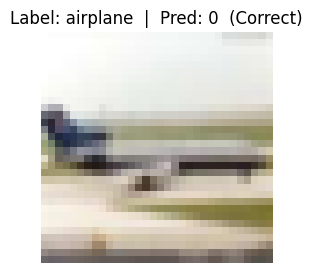

Label: airplane | Pred: 0 | Confidence: 100.00%


In [ ]:
# 학습을 마친 모델에게 "자, 이제 실전 문제 하나 풀어봐!"라고 개별 테스트를 시키는 코드
# 무작위로 사진 한 장을 골라 모델의 예측값과 실제 정답을 비교하고, 모델이 얼마나 자신 있게(Confidence) 답했는지 확인하는 과정

import random

idx = random.randint(0, len(test_data) - 1)
# 테스트 데이터셋 중에서 무작위로 번호(인덱스) 하나를 뽑음

img, label = test_data[idx]
# 해당 번호의 이미지(img)와 진짜 정답(label)을 가져옴

model.eval()
# 평가모드

with torch.no_grad():   # 텐서는 연산 시 기울기를 계산하는데, 테스트 시에는 가중치를 업데이트할 필요는 없지만, 평가 시에는 필요 없음.
    logits = model(img.unsqueeze(0).to(device))
    # img.unsqueeze(0): 모델은 항상 '배치' 형태(뭉치)를 입력받길 원함, 이미지 한 장(3, 32, 32)을 (1, 3, 32, 32)로 차원을 하나 늘려 "1장짜리 배치"로 만들어주는 작업
    # .to(device): 이미지를 모델이 있는 장치(GPU 등)로 보냄

probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
# softmax: 점수(logits)를 합계가 100%인 확률로 바꾸고
# squeeze: 아까 늘렸던 '1장' 차원을 다시 없애서 1차원 리스트로 만들고
# cpu().numpy(): 시각화를 위해 GPU에 있는 데이터를 CPU로 가져오고 넘파이 배열로 바꿈

pred  = probs.argmax()
# 10개의 확률 중 가장 높은 값의 인덱스(번호)를 최종 예측값으로 선택

fig, ax1 = plt.subplots(1, 1, figsize=(8, 3))
# 무작위로 뽑은 이 사진 한 장에만 집중해서 결과랑 확률을 자세히 볼래라는 뜻

plt.imshow(img.permute(1, 2, 0))      # 차원 또 바꿈
ax1.set_title(f'Label: {classes[label]}  |  Pred: {pred}  ({"Correct" if pred==label else "Wrong"})')
ax1.axis('off')

plt.show()
print(f'Label: {classes[label]} | Pred: {pred} | Confidence: {probs[pred]:.2%}')

# "테스트셋에서 아무 사진이나 한 장 꺼내서, 모델에게 물어보고, 그 결과와 확신도를 사진과 함께 보여줘!"라는 코드
